### Formulation of the problem (Step 3 — Center Relocation)

#### Variables, Sets, Data:

- $B = \{1, 2, \dots, n\}$ : set of bricks  
- $S = \{1, 2, \dots, m\}$ : set of potential center locations  
- $w_i$ : workload associated with brick $i$  
- $d_{i,j}$ : distance between brick $i$ and center $j$

**Decision variables:**

- $x_{i,j} = 1$ if brick $i$ is assigned to center $j$, else $0$  
- $y_j = 1$ if a center is opened at brick $j$, else $0$  
- $wm \ge 0$ : maximum workload across centers  

---

#### Constraints:

**1) Unique assignment:**
$$
\sum_{j \in S} x_{i,j} = 1 \quad \forall i \in B
$$

**2) Exactly \( n \) centers opened:**
$$
\sum_{j \in S} y_j = n
$$

**3) Assignment only if the center is opened:**
$$
x_{i,j} \le y_j \quad \forall i \in B, \forall j \in S
$$

**4) Workload of center \( j \):**
$$
\text{load}_j = \sum_{i \in B} w_i \, x_{i,j}
$$

**5) Definition of maximum workload:**
$$
wm \ge \text{load}_j \quad \forall j \in S
$$

---

#### Objective Function (Distance Minimization):

$$
\min \sum_{i \in B}\sum_{j \in S} d_{i,j} \, x_{i,j}
$$

---

#### Workload Balancing Trade-off (ε-Constraint Approach):

To explore the balance between efficiency and fairness, we progressively restrict $wm$:

$$
wm \le \varepsilon
$$

and resolve the optimization for increasing values of $\varepsilon$

In [21]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd

distances = pd.read_excel("distances.xlsx", sheet_name=1, header=None).iloc[2:, 2:]
n = 4 #nb SR
m = 22 # nb bricks

workloads = [0.1609, 0.1164, 0.1026, 0.1516, 0.0939, 
     0.1320, 0.0687, 0.0930, 0.2116, 0.2529, 
     0.0868, 0.0828, 0.0975, 0.8177, 0.4115, 
     0.3795, 0.0710, 0.0427, 0.1043, 0.0997, 
     0.1698, 0.2531]

## Minimize the total distance

In [22]:
model = gp.Model("step3")
model.Params.OutputFlag = 0

# --- Variables ---

# x[i,j] = 1 si brick i est servi par un centre placé au brick j
x = model.addVars(m, m, vtype=GRB.BINARY, name="x")

# y[j] = 1 si on place un centre sur le brick j
y = model.addVars(m, vtype=GRB.BINARY, name="y")

# wm = workload maximal (variable continue)
wm = model.addVar(vtype=GRB.CONTINUOUS, lb=0.0, name="wm")

# --- Contraintes ---

# 1) Chaque brick i est servi par exactement un centre
for i in range(m):
    model.addConstr(gp.quicksum(x[i,j] for j in range(m)) == 1)

# 2) On ouvre exactement n centres
model.addConstr(gp.quicksum(y[j] for j in range(m)) == n)

# 3) Pas d’affectation si le centre n’est pas ouvert
for i in range(m):
    for j in range(m):
        model.addConstr(x[i,j] <= y[j])

# 4) Lien au max : wm >= charge_j pour tout centre j (ou SR j)
for j in range(m):
    model.addConstr(wm >= gp.quicksum(workloads[i]*x[i,j] for i in range(m)))


# --- Objective function 1 : Minimize the total distance ---
dist_expr = gp.quicksum(distances.iloc[i,j] * x[i,j]
                                for i in range(m)
                                for j in range(m))

model.setObjective(dist_expr, GRB.MINIMIZE)

model.optimize()

In [23]:
y_sol = [j for j in range(m) if model.getVarByName(f"y[{j}]").X > 0.5]
print(f"Centers : {[j+1 for j in y_sol]}")

for j in y_sol:
    bricks_j = [i+1 for i in range(m) if model.getVarByName(f"x[{i},{j}]").X > 0.5]
    load_j = sum(workloads[i]*model.getVarByName(f"x[{i},{j}]").X for i in range(m))
    print(f" Center at brick {j+1:2d} -> bricks {bricks_j}, load = {load_j:.2f}")


dist_val = dist_expr.getValue()
wm_val = model.getVarByName("wm").X
print(f"Total distance = {dist_val:.2f}")


loads = []
for j in range(m):
    load_j = sum(workloads[i] * model.getVarByName(f"x[{i},{j}]").X for i in range(m))
    loads.append(load_j)
wm_max = max(loads)

print(f"Workload max = {wm_max:.2f}")


Centers : [2, 6, 12, 15]
 Center at brick  2 -> bricks [1, 2, 3, 19, 20, 21, 22], load = 1.01
 Center at brick  6 -> bricks [4, 5, 6, 7, 8, 9], load = 0.75
 Center at brick 12 -> bricks [12], load = 0.08
 Center at brick 15 -> bricks [10, 11, 13, 14, 15, 16, 17, 18], load = 2.16
Total distance = 88.30
Workload max = 2.16


## Minimize the maximal workload by SR

In [24]:
model.setObjective(model.getVarByName("wm"), GRB.MINIMIZE)
model.optimize()

y_sol = [j for j in range(m) if model.getVarByName(f"y[{j}]").X > 0.5]
print(f"Centers : {[j+1 for j in y_sol]}")

for j in y_sol:
    bricks_j = [i+1 for i in range(m) if model.getVarByName(f"x[{i},{j}]").X > 0.5]
    load_j = sum(workloads[i]*model.getVarByName(f"x[{i},{j}]").X for i in range(m))
    print(f" Center at brick {j+1:2d} -> bricks {bricks_j}, load = {load_j:.2f}")


# Objectif & charge max
wm_val = model.getVarByName("wm").X
print(f"Total distance = {dist_expr.getValue():.2f}")
print(f"Workload max = {wm_val:.2f}")

Centers : [1, 2, 3, 4]
 Center at brick  1 -> bricks [1, 5, 6, 8, 11, 12, 13, 22], load = 1.00
 Center at brick  2 -> bricks [7, 14, 17, 18], load = 1.00
 Center at brick  3 -> bricks [2, 4, 10, 16, 20], load = 1.00
 Center at brick  4 -> bricks [3, 9, 15, 19, 21], load = 1.00
Total distance = 425.19
Workload max = 1.00


## Minimize the total distance regarding the workload

In [25]:
m_wmin = model.copy()
m_wmin.setObjective(m_wmin.getVarByName("wm"), GRB.MINIMIZE)
m_wmin.optimize()
wm_min = m_wmin.getVarByName("wm").X
wm_max = sum(workloads)

print(f"wm_min = {wm_min:.2f} | wm_max ≈ {wm_max:.2f}")

wm_min = 1.00 | wm_max ≈ 4.00


ε=1.0100  →  wm=1.0068,  dist*=110.97
ε=1.0200  →  wm=1.0068,  dist*=110.97
ε=1.0300  →  wm=1.0068,  dist*=110.97
ε=1.0400  →  wm=1.0068,  dist*=110.97
ε=1.0500  →  wm=1.0439,  dist*=109.33
ε=1.0600  →  wm=1.0439,  dist*=109.33
ε=1.0700  →  wm=1.0439,  dist*=109.33
ε=1.0800  →  wm=1.0439,  dist*=109.33
ε=1.0900  →  wm=1.0866,  dist*=106.60
ε=1.1000  →  wm=1.0866,  dist*=106.60
ε=1.1100  →  wm=1.0866,  dist*=106.60
ε=1.1200  →  wm=1.1149,  dist*=105.06
ε=1.1300  →  wm=1.1149,  dist*=105.06
ε=1.1400  →  wm=1.1307,  dist*=103.56
ε=1.1500  →  wm=1.1307,  dist*=103.56
ε=1.1600  →  wm=1.1307,  dist*=103.56
ε=1.1700  →  wm=1.1307,  dist*=103.56
ε=1.1800  →  wm=1.1307,  dist*=103.56
ε=1.1900  →  wm=1.1307,  dist*=103.56
ε=1.2000  →  wm=1.1307,  dist*=103.56
ε=1.2100  →  wm=1.2017,  dist*=103.42
ε=1.2200  →  wm=1.2017,  dist*=103.42
ε=1.2300  →  wm=1.2017,  dist*=103.42
ε=1.2400  →  wm=1.2017,  dist*=103.42
ε=1.2500  →  wm=1.2444,  dist*=102.79
ε=1.2600  →  wm=1.2444,  dist*=102.79
ε=1.2700  → 

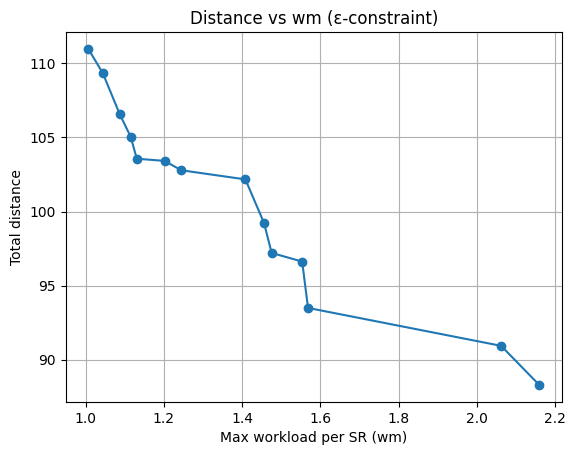

In [15]:
import numpy as np
import matplotlib.pyplot as plt

eps_grid = np.arange(1.01, 4, 0.01)

# garder seulement les eps faisables
# eps_grid = [eps for eps in eps_grid if eps + 1e-9 >= wm_min]
eps_grid = [eps for eps in eps_grid if eps + 1e-9 >= wm_min]

pareto_points = []   # (wm_val, dist_val)

# ---Epsilon-constraint loop ---
for eps in eps_grid:
    m2 = model.copy()

    m2.addConstr(m2.getVarByName("wm") <= eps + 1e-9, name=f"wm_cap_{eps}")

    # objectif : distance + micro tie-break sur wm
    dist2 = gp.quicksum(
        distances.iloc[i, j] * m2.getVarByName(f"x[{i},{j}]")
        for i in range(m) for j in range(m)
    )
    m2.setObjective(dist2 + 1e-9 * m2.getVarByName("wm"), GRB.MINIMIZE)

    m2.optimize()
    if m2.status == GRB.OPTIMAL:
        wm_val = m2.getVarByName("wm").X
        dist_val = dist2.getValue()
        pareto_points.append((wm_val, dist_val))
        print(f"ε={eps:.4f}  →  wm={wm_val:.4f},  dist*={dist_val:.2f}")
    else:
        print(f"ε={eps:.4f}  →  INFEASIBLE")


# suppress duplicates
seen = set()
pareto_nd = []
for wm_val, dist_val in pareto_points:
    key = (round(wm_val,6), round(dist_val,6))
    if key not in seen:
        seen.add(key)
        pareto_nd.append((wm_val, dist_val))

pareto_nd.sort(key=lambda t: (t[0], t[1]))

# plot
if pareto_nd:
    xs = [p[0] for p in pareto_nd]  # wm
    ys = [p[1] for p in pareto_nd]  # distance
    plt.plot(xs, ys, 'o-')
    plt.xlabel("Max workload per SR (wm)")
    plt.ylabel("Total distance")
    plt.title("Distance vs wm (ε-constraint)")
    plt.grid(True)
    plt.show()